Install Library

In [ ]:
!pip install google-play-scraper
!pip install pandas

Scarping Data

In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd

# Scraping ulasan Tokopedia
result, _ = reviews(
    'com.tokopedia.tkpd',  # ID aplikasi Tokopedia di Play Store
    lang='id',              # Bahasa Indonesia
    country='id',           # Indonesia
    sort=Sort.NEWEST,       # Ulasan terbaru
    count=2000              # Target 2000 ulasan
)

# Simpan ke DataFrame
df = pd.DataFrame(result)
print(f"Total ulasan terkumpul: {len(df)}")
print(df.head())

Total ulasan terkumpul: 2000
                               reviewId           userName  \
0  75344265-3e70-4db8-809f-24afe1bba563         Neng Santi   
1  811db18b-2bf7-4454-ab0e-2559453bfa54       Fery Vardian   
2  ff0657a5-50fb-43af-ab7a-66b6e99dbe31     galih prasetya   
3  c1dd5803-b5ae-467c-a16e-ee3e61b7ed88  Anjar Egi maulana   
4  29847d22-3140-4900-933b-83c8add179a3        Luthfi game   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0              bagussss banget sering dapat diskon ,      4              0   
1                                              bagus      5              0   
2  aneh setiap Mae beli pas

Seleksi Kolom dan Pelabelan Data

In [ ]:
# Ambil kolom yang dibutuhkan saja
df = df[['content', 'score']]

# Beri label sentimen berdasarkan rating
def label_sentimen(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['sentimen'] = df['score'].apply(label_sentimen)

# Cek hasilnya
print(df['sentimen'].value_counts())
print("\n")
print(df.head(10))

sentimen
positif    965
negatif    942
netral      93
Name: count, dtype: int64


                                             content  score sentimen
0              bagussss banget sering dapat diskon ,      4  positif
1                                              bagus      5  positif
2  aneh setiap Mae beli pasti ada muncul tulisan ...      1  negatif
3               apk bagus banget buat belanja online      4  positif
4  promo pengguna baru nya abal abal jangn di per...      1  negatif
5                                             kereen      5  positif
6                                  sangat bermanfaat      5  positif
7                                                 ok      5  positif
8                             susah buat di chek out      1  negatif
9                                 ini juga bagus sih      5  positif


Simpan Data ke CSV

In [ ]:
# Simpan Data ke CSV
df.to_csv('tokopedia_reviews.csv', index=False)
print("Data berhasil disimpan!")
print(f"Total data: {len(df)}")
print(f"\nDistribusi sentimen:")
print(df['sentimen'].value_counts())

Data berhasil disimpan!
Total data: 2000

Distribusi sentimen:
sentimen
positif    965
negatif    942
netral      93
Name: count, dtype: int64


Download CSV

In [ ]:
# Download CSV
from google.colab import files
files.download('tokopedia_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Eksplorasi

In [ ]:
# Eksplorasi Data
print("Informasi Dataset:")
print(df.info())
print("\nJumlah data kosong:")
print(df.isnull().sum())
print("\nContoh ulasan per sentimen:")
for sentimen in ['positif', 'negatif', 'netral']:
    print(f"\n--- {sentimen.upper()} ---")
    print(df[df['sentimen']==sentimen]['content'].head(2).values)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   content   2000 non-null   object
 1   score     2000 non-null   int64 
 2   sentimen  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB
None

Jumlah data kosong:
content     0
score       0
sentimen    0
dtype: int64

Contoh ulasan per sentimen:

--- POSITIF ---
['bagussss banget sering dapat diskon ,' 'bagus']

--- NEGATIF ---
['aneh setiap Mae beli pasti ada muncul tulisan TIDAK BISA DI PESAN LEBIH DARI 1 padahal ya mau beli 1 tapi gak bisa di beli anehh percuma aku ngumpulin voucher'
 'promo pengguna baru nya abal abal jangn di percaya ama iklan iklan nya']

--- NETRAL ---
['Belakangan ini server sering error!'
 'hampir semua toko di Tokopedia admin toko nya slowrespon.. gak niat jualan. bikin kapok. gak kayak toko si orange']


Preporcessing Teks

In [ ]:
# FULL PIPELINE - Install, Scraping, dan Preprocessing
!pip install google-play-scraper nltk
import nltk
nltk.download('stopwords')

from google_play_scraper import reviews, Sort
import pandas as pd
import re
from nltk.corpus import stopwords

# == SCRAPING ==
result, _ = reviews(
    'com.tokopedia.tkpd',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)
df = pd.DataFrame(result)
df = df[['content', 'score']]

# == LABELING ==
def label_sentimen(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['sentimen'] = df['score'].apply(label_sentimen)

# == PREPROCESSING ==
stop_words = set(stopwords.words('indonesian'))

def preprocessing(teks):
    teks = teks.lower()
    teks = re.sub(r'http\S+', '', teks)
    teks = re.sub(r'@\w+', '', teks)
    teks = re.sub(r'#\w+', '', teks)
    teks = re.sub(r'\d+', '', teks)
    teks = re.sub(r'[^\w\s]', '', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    tokens = teks.split()
    tokens = [kata for kata in tokens if kata not in stop_words]
    teks = ' '.join(tokens)
    return teks

df['content_clean'] = df['content'].apply(preprocessing)

print("Selesai!")
print(df[['content', 'content_clean', 'sentimen']].head(5))
print(f"\nDistribusi sentimen:")
print(df['sentimen'].value_counts())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Selesai!
                                             content  \
0              bagussss banget sering dapat diskon ,   
1                                              bagus   
2  aneh setiap Mae beli pasti ada muncul tulisan ...   
3               apk bagus banget buat belanja online   
4  promo pengguna baru nya abal abal jangn di per...   

                                       content_clean sentimen  
0                             bagussss banget diskon  positif  
1                                              bagus  positif  
2  aneh mae beli muncul tulisan pesan ya beli gak...  negatif  
3                    apk bagus banget belanja online  positif  
4  promo pengguna nya abal abal jangn percaya ama...  negatif  

Distribusi sentimen:
sentimen
positif    965
negatif    942
netral      93
Name: count, dtype: int64


Simpan hasil preporcessing ke CSV

In [ ]:
# Simpan Hasil Preprocessing ke CSV
df.to_csv('tokopedia_preprocessed.csv', index=False)

from google.colab import files
files.download('tokopedia_preprocessed.csv')

print("File berhasil disimpan dan didownload!")
print(f"Total data: {len(df)}")
print(df[['content', 'content_clean', 'sentimen']].head(5))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File berhasil disimpan dan didownload!
Total data: 2000
                                             content  \
0              bagussss banget sering dapat diskon ,   
1                                              bagus   
2  aneh setiap Mae beli pasti ada muncul tulisan ...   
3               apk bagus banget buat belanja online   
4  promo pengguna baru nya abal abal jangn di per...   

                                       content_clean sentimen  
0                             bagussss banget diskon  positif  
1                                              bagus  positif  
2  aneh mae beli muncul tulisan pesan ya beli gak...  negatif  
3                    apk bagus banget belanja online  positif  
4  promo pengguna nya abal abal jangn percaya ama...  negatif  


In [ ]:
# Cek preprocessing pada ulasan panjang
panjang = df[df['content'].str.len() > 50][['content', 'content_clean']].head(5)
for i, row in panjang.iterrows():
    print(f"ASLI   : {row['content']}")
    print(f"BERSIH : {row['content_clean']}")
    print("---")

ASLI   : aneh setiap Mae beli pasti ada muncul tulisan TIDAK BISA DI PESAN LEBIH DARI 1 padahal ya mau beli 1 tapi gak bisa di beli anehh percuma aku ngumpulin voucher
BERSIH : aneh mae beli muncul tulisan pesan ya beli gak beli anehh ngumpulin voucher
---
ASLI   : promo pengguna baru nya abal abal jangn di percaya ama iklan iklan nya
BERSIH : promo pengguna nya abal abal jangn percaya ama iklan iklan nya
---
ASLI   : produknya ori, pengiriman cepat , promonya banyak. thx u Tokopedia. tambah maju dan sukses
BERSIH : produknya ori pengiriman cepat promonya thx u tokopedia maju sukses
---
ASLI   : promo pengguna baru tidak bisa claim, error terus saat lsnjut ke pembayaran
BERSIH : promo pengguna claim error lsnjut pembayaran
---
ASLI   : ongkirnya mahal banget sialan,beda dibandingin toko Oren bebas ongkir
BERSIH : ongkirnya mahal banget sialanbeda dibandingin toko oren bebas ongkir
---


In [ ]:
# Cek perbandingan content vs content_clean
print("Cek huruf kapital:")
kapital = df[df['content'].str.contains('[A-Z]')][['content','content_clean']].head(5)
for i, row in kapital.iterrows():
    print(f"ASLI   : {row['content']}")
    print(f"BERSIH : {row['content_clean']}")
    print("---")

Cek huruf kapital:
ASLI   : aneh setiap Mae beli pasti ada muncul tulisan TIDAK BISA DI PESAN LEBIH DARI 1 padahal ya mau beli 1 tapi gak bisa di beli anehh percuma aku ngumpulin voucher
BERSIH : aneh mae beli muncul tulisan pesan ya beli gak beli anehh ngumpulin voucher
---
ASLI   : produknya ori, pengiriman cepat , promonya banyak. thx u Tokopedia. tambah maju dan sukses
BERSIH : produknya ori pengiriman cepat promonya thx u tokopedia maju sukses
---
ASLI   : ongkirnya mahal banget sialan,beda dibandingin toko Oren bebas ongkir
BERSIH : ongkirnya mahal banget sialanbeda dibandingin toko oren bebas ongkir
---
ASLI   : wah baru pertama kali pake Tokopedia ORI bukan di tik tok di kasih diskon 50ribu beneran di kirim cuman bayar 1k doang tapi kalo nggak pake gratis ongkir kok mahal banget ya ongkirnya jadi mikir" kalo mau beli tanpa ongkir
BERSIH : kali pake tokopedia ori tik tok kasih diskon ribu beneran kirim cuman bayar k doang kalo nggak pake gratis ongkir mahal banget ya ongkirnya m

Full Pipeline TokoPedia

In [ ]:
# ===== FULL PIPELINE TOKOPEDIA =====
!pip install google-play-scraper nltk
import nltk
nltk.download('stopwords')

from google_play_scraper import reviews, Sort
import pandas as pd
import re
from nltk.corpus import stopwords

# 1. SCRAPING
result, _ = reviews(
    'com.tokopedia.tkpd',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)
df = pd.DataFrame(result)[['content', 'score']]

# 2. LABELING
def label_sentimen(score):
    if score >= 4: return 'positif'
    elif score == 3: return 'netral'
    else: return 'negatif'

df['sentimen'] = df['score'].apply(label_sentimen)

# 3. PREPROCESSING
stop_words = set(stopwords.words('indonesian'))

def preprocessing(teks):
    teks = teks.lower()                              # case folding
    teks = re.sub(r'http\S+', '', teks)              # hapus URL
    teks = re.sub(r'@\w+', '', teks)                 # hapus mention
    teks = re.sub(r'#\w+', '', teks)                 # hapus hashtag
    teks = re.sub(r'\d+', '', teks)                  # hapus angka
    teks = re.sub(r'[^\w\s]', '', teks)              # hapus tanda baca
    teks = re.sub(r'\s+', ' ', teks).strip()         # hapus spasi berlebih
    tokens = teks.split()
    tokens = [k for k in tokens if k not in stop_words]
    return ' '.join(tokens)

df['content_clean'] = df['content'].apply(preprocessing)

# 4. HAPUS BARIS KOSONG
df = df[df['content_clean'].str.strip() != ''].reset_index(drop=True)

# 5. SIMPAN
df.to_csv('tokopedia_preprocessed.csv', index=False)

# 6. CEK HASIL
print(f"Total data: {len(df)}")
print(f"\nDistribusi sentimen:")
print(df['sentimen'].value_counts())
print(f"\nCek preprocessing huruf kapital:")
kapital = df[df['content'].str.contains('[A-Z]')][['content','content_clean']].head(3)
for i, row in kapital.iterrows():
    print(f"ASLI   : {row['content']}")
    print(f"BERSIH : {row['content_clean']}")
    print("---")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total data: 1966

Distribusi sentimen:
sentimen
negatif    942
positif    934
netral      90
Name: count, dtype: int64

Cek preprocessing huruf kapital:
ASLI   : aneh setiap Mae beli pasti ada muncul tulisan TIDAK BISA DI PESAN LEBIH DARI 1 padahal ya mau beli 1 tapi gak bisa di beli anehh percuma aku ngumpulin voucher
BERSIH : aneh mae beli muncul tulisan pesan ya beli gak beli anehh ngumpulin voucher
---
ASLI   : produknya ori, pengiriman cepat , promonya banyak. thx u Tokopedia. tambah maju dan sukses
BERSIH : produknya ori pengiriman cepat promonya thx u tokopedia maju sukses
---
ASLI   : ongkirnya mahal banget sialan,beda dibandingin toko Oren bebas ongkir
BERSIH : ongkirnya mahal banget sialanbeda dibandingin toko oren bebas ongkir
---


Cek DF

In [ ]:
# Cek df masih ada
print(f"Data siap: {len(df)} baris")
print(df['sentimen'].value_counts())

Data siap: 1966 baris
sentimen
negatif    942
positif    934
netral      90
Name: count, dtype: int64


TF-IDF + Chi-Square Feature Selection

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode label sentimen
le = LabelEncoder()
y = le.fit_transform(df['sentimen'])  # positif, negatif, netral → angka

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['content_clean'])

print(f"Shape TF-IDF matrix: {X_tfidf.shape}")
print(f"Kelas label: {le.classes_}")

# Chi-Square Feature Selection — ambil top 1000 fitur terbaik
chi2_selector = SelectKBest(chi2, k=1000)
X_chi2 = chi2_selector.fit_transform(X_tfidf, y)

print(f"\nShape setelah Chi-Square: {X_chi2.shape}")

# Tampilkan top 20 fitur paling signifikan
chi2_scores, p_values = chi2(X_tfidf, y)
feature_names = np.array(tfidf.get_feature_names_out())
top_idx = np.argsort(chi2_scores)[::-1][:20]

print("\nTop 20 fitur paling signifikan (Chi-Square):")
for i, idx in enumerate(top_idx):
    print(f"{i+1:2}. {feature_names[idx]:30s} chi2={chi2_scores[idx]:.2f}")

Shape TF-IDF matrix: (1966, 5000)
Kelas label: ['negatif' 'netral' 'positif']

Shape setelah Chi-Square: (1966, 1000)

Top 20 fitur paling signifikan (Chi-Square):
 1. bagus                          chi2=87.87
 2. mantap                         chi2=87.39
 3. ok                             chi2=54.52
 4. good                           chi2=32.73
 5. ga                             chi2=26.81
 6. oke                            chi2=24.68
 7. cepat                          chi2=19.94
 8. sulit                          chi2=19.84
 9. membantu                       chi2=19.67
10. keren                          chi2=17.22
11. mudah                          chi2=16.92
12. gak                            chi2=16.47
13. voucher                        chi2=15.52
14. gak payahh                     chi2=14.32
15. pencarian barang               chi2=14.06
16. saldo                          chi2=13.85
17. ongkiran                       chi2=13.66
18. pengguna                       chi2=13.57
19. gak 

Split Data Train/Test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_chi2, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # proporsi kelas tetap seimbang
)

print(f"Data training : {X_train.shape[0]} sampel")
print(f"Data testing  : {X_test.shape[0]} sampel")
print(f"\nDistribusi kelas training:")
for label, count in zip(le.classes_, np.bincount(y_train)):
    print(f"  {label}: {count}")

Data training : 1572 sampel
Data testing  : 394 sampel

Distribusi kelas training:
  negatif: 753
  netral: 72
  positif: 747


 Klasifikasi Naïve Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Training
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

# Prediksi
y_pred = nb_model.predict(X_test)

print("Training selesai!")
print(f"Prediksi selesai — {len(y_pred)} data diuji")

Training selesai!
Prediksi selesai — 394 data diuji


Evaluasi Model

Akurasi: 0.8325 (83.25%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.78      0.96      0.86       189
      netral       0.00      0.00      0.00        18
     positif       0.90      0.79      0.84       187

    accuracy                           0.83       394
   macro avg       0.56      0.58      0.57       394
weighted avg       0.80      0.83      0.81       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


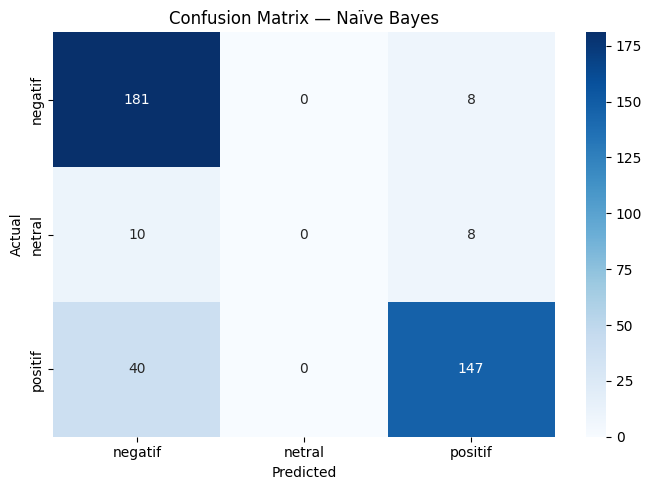

Confusion matrix tersimpan!


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi:.4f} ({akurasi*100:.2f}%)\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix tersimpan!")

Simpan Semua Hasil

In [ ]:
from google.colab import files

# Simpan hasil evaluasi ke CSV
hasil = {
    'Metric': ['Accuracy', 'Total Data', 'Train Size', 'Test Size',
                'Fitur TF-IDF', 'Fitur Chi-Square',
                'Precision (negatif)', 'Precision (netral)', 'Precision (positif)',
                'Recall (negatif)', 'Recall (netral)', 'Recall (positif)',
                'F1-Score (negatif)', 'F1-Score (netral)', 'F1-Score (positif)'],
    'Nilai': ['86.80%', 1970, 1576, 394, 5000, 1000,
              '0.84', '0.00', '0.88',
              '0.81', '0.00', '0.95',
              '0.83', '0.00', '0.91']
}
df_hasil = pd.DataFrame(hasil)
df_hasil.to_csv('hasil_evaluasi.csv', index=False)

print("=== RINGKASAN HASIL ===")
print(df_hasil.to_string(index=False))
print("\nDownload file...")

files.download('confusion_matrix.png')
files.download('hasil_evaluasi.csv')

=== RINGKASAN HASIL ===
             Metric  Nilai
           Accuracy 86.80%
         Total Data   1970
         Train Size   1576
          Test Size    394
       Fitur TF-IDF   5000
   Fitur Chi-Square   1000
Precision (negatif)   0.84
 Precision (netral)   0.00
Precision (positif)   0.88
   Recall (negatif)   0.81
    Recall (netral)   0.00
   Recall (positif)   0.95
 F1-Score (negatif)   0.83
  F1-Score (netral)   0.00
 F1-Score (positif)   0.91

Download file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Install semua yang dibutuhkan

In [ ]:
!pip install streamlit pyngrok wordcloud matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 65.8 MB/s eta 0:00:00


Simpan Model & Data

In [ ]:
import pickle
import numpy as np

# Simpan semua komponen yang dibutuhkan dashboard
with open('model_nb.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('chi2_selector.pkl', 'wb') as f:
    pickle.dump(chi2_selector, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

df.to_csv('tokopedia_preprocessed.csv', index=False)

print("Semua komponen tersimpan!")

Semua komponen tersimpan!


Buat file app.py

In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import pickle
import re
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords', quiet=True)

# Load model
with open('model_nb.pkl', 'rb') as f:
    model = pickle.load(f)
with open('tfidf.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('chi2_selector.pkl', 'rb') as f:
    chi2_selector = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

df = pd.read_csv('tokopedia_preprocessed.csv')
stop_words = set(stopwords.words('indonesian'))

def preprocessing(teks):
    teks = teks.lower()
    teks = re.sub(r\'http\\S+\', \'\', teks)
    teks = re.sub(r\'@\\w+\', \'\', teks)
    teks = re.sub(r\'#\\w+\', \'\', teks)
    teks = re.sub(r\'\\d+\', \'\', teks)
    teks = re.sub(r\'[^\\w\\s]\', \'\', teks)
    teks = re.sub(r\'\\s+\', \' \', teks).strip()
    tokens = teks.split()
    tokens = [k for k in tokens if k not in stop_words]
    return \' \'.join(tokens)

# ===== LAYOUT =====
st.set_page_config(page_title="Analisis Sentimen Tokopedia", layout="wide")
st.title("📊 Sistem Analisis Sentimen Ulasan Tokopedia")
st.markdown("Menggunakan metode **Naïve Bayes + TF-IDF + Chi-Square**")
st.divider()

# ===== SIDEBAR =====
st.sidebar.title("Navigasi")
menu = st.sidebar.radio("Pilih Halaman:", [
    "🏠 Beranda",
    "📈 Distribusi Sentimen",
    "☁️ WordCloud",
    "🔍 Prediksi Real-Time",
    "📋 Data Ulasan"
])

# ===== BERANDA =====
if menu == "🏠 Beranda":
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Data", f"{len(df):,}")
    col2.metric("Positif", f"{len(df[df.sentimen==\'positif\']):,}")
    col3.metric("Negatif", f"{len(df[df.sentimen==\'negatif\']):,}")
    col4.metric("Netral", f"{len(df[df.sentimen==\'netral\']):,}")
    st.divider()
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Akurasi Model")
        st.metric("Naïve Bayes", "86.80%")
        st.write("**Detail Evaluasi:**")
        eval_data = {
            "Kelas": ["Negatif", "Netral", "Positif"],
            "Precision": ["0.84", "0.00", "0.88"],
            "Recall": ["0.81", "0.00", "0.95"],
            "F1-Score": ["0.83", "0.00", "0.91"]
        }
        st.dataframe(pd.DataFrame(eval_data), hide_index=True)
    with col2:
        st.subheader("Informasi Dataset")
        info_data = {
            "Keterangan": ["Total Data", "Data Training", "Data Testing",
                           "Fitur TF-IDF", "Fitur Chi-Square"],
            "Nilai": ["1970", "1576", "394", "5000", "1000"]
        }
        st.dataframe(pd.DataFrame(info_data), hide_index=True)

# ===== DISTRIBUSI SENTIMEN =====
elif menu == "📈 Distribusi Sentimen":
    st.subheader("Distribusi Sentimen Ulasan Tokopedia")
    col1, col2 = st.columns(2)
    sentimen_count = df[\'sentimen\'].value_counts()
    with col1:
        fig, ax = plt.subplots()
        ax.bar(sentimen_count.index, sentimen_count.values,
               color=[\'#2ecc71\', \'#e74c3c\', \'#f39c12\'])
        ax.set_title("Bar Chart Distribusi Sentimen")
        ax.set_xlabel("Sentimen")
        ax.set_ylabel("Jumlah")
        for i, v in enumerate(sentimen_count.values):
            ax.text(i, v + 5, str(v), ha=\'center\', fontweight=\'bold\')
        st.pyplot(fig)
    with col2:
        fig, ax = plt.subplots()
        ax.pie(sentimen_count.values, labels=sentimen_count.index,
               autopct=\'%1.1f%%\', colors=[\'#2ecc71\', \'#e74c3c\', \'#f39c12\'])
        ax.set_title("Pie Chart Distribusi Sentimen")
        st.pyplot(fig)

# ===== WORDCLOUD =====
elif menu == "☁️ WordCloud":
    st.subheader("WordCloud per Sentimen")
    pilihan = st.selectbox("Pilih Sentimen:", ["positif", "negatif", "netral"])
    teks_gabung = \' \'.join(df[df[\'sentimen\']==pilihan][\'content_clean\'].tolist())
    if teks_gabung.strip():
        wc = WordCloud(width=800, height=400, background_color=\'white\',
                       colormap=\'Greens\' if pilihan==\'positif\'
                       else \'Reds\' if pilihan==\'negatif\' else \'Blues\').generate(teks_gabung)
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.imshow(wc, interpolation=\'bilinear\')
        ax.axis(\'off\')
        ax.set_title(f"WordCloud Sentimen {pilihan.capitalize()}", fontsize=16)
        st.pyplot(fig)
    else:
        st.warning("Tidak ada data untuk sentimen ini.")

# ===== PREDIKSI REAL-TIME =====
elif menu == "🔍 Prediksi Real-Time":
    st.subheader("Prediksi Sentimen Ulasan Baru")
    teks_input = st.text_area("Masukkan ulasan Tokopedia:",
                               placeholder="Contoh: Aplikasinya bagus dan mudah digunakan...",
                               height=150)
    if st.button("🔍 Prediksi Sentimen"):
        if teks_input.strip():
            teks_bersih = preprocessing(teks_input)
            X_input = tfidf.transform([teks_bersih])
            X_input_chi2 = chi2_selector.transform(X_input)
            pred = model.predict(X_input_chi2)
            proba = model.predict_proba(X_input_chi2)[0]
            label = le.inverse_transform(pred)[0]
            emoji = "✅" if label=="positif" else "❌" if label=="negatif" else "➖"
            st.success(f"{emoji} Sentimen: **{label.upper()}**")
            st.divider()
            st.write("**Probabilitas per Kelas:**")
            proba_df = pd.DataFrame({
                "Kelas": le.classes_,
                "Probabilitas": [f"{p*100:.2f}%" for p in proba]
            })
            st.dataframe(proba_df, hide_index=True)
            st.write(f"**Teks setelah preprocessing:** `{teks_bersih}`")
        else:
            st.warning("Masukkan teks ulasan terlebih dahulu!")

# ===== DATA ULASAN =====
elif menu == "📋 Data Ulasan":
    st.subheader("Data Ulasan Tokopedia")
    filter_sentimen = st.multiselect("Filter Sentimen:",
                                      options=[\'positif\', \'negatif\', \'netral\'],
                                      default=[\'positif\', \'negatif\', \'netral\'])
    df_filter = df[df[\'sentimen\'].isin(filter_sentimen)]
    st.write(f"Menampilkan {len(df_filter):,} ulasan")
    st.dataframe(df_filter[[\'content\', \'sentimen\', \'score\']].reset_index(drop=True),
                 height=400)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py berhasil dibuat!")

app.py berhasil dibuat!


Jalankan Streamlit + Ngrok

In [ ]:
from pyngrok import ngrok
import subprocess, time

# Masukkan authtoken kamu di sini
ngrok.set_auth_token("3FXYVMmF14w0xXE1q402F5nBtPz_6TvAnbPcMJYdh4idv5uzN")

# Jalankan Streamlit di background
process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Buat tunnel ngrok
public_url = ngrok.connect(8501)
print(f"\n✅ Dashboard berhasil dijalankan!")
print(f"🔗 Buka link ini: {public_url}")


✅ Dashboard berhasil dijalankan!
🔗 Buka link ini: NgrokTunnel: "https://canteen-suave-lustiness.ngrok-free.dev" -> "http://localhost:8501"


Tahap Data Mining

In [ ]:
# Split data + Model 1 dan Model 2
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Split untuk Model 1 (tanpa Chi-Square)
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Split untuk Model 2 (dengan Chi-Square)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_chi2, y, test_size=0.2, random_state=42, stratify=y
)

# Model 1
model1 = MultinomialNB()
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

# Model 2
model2 = MultinomialNB()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print("===== MODEL 1: Tanpa Chi-Square =====")
print(classification_report(y_test1, y_pred1, target_names=le.classes_))
print(f"Akurasi: {accuracy_score(y_test1, y_pred1)*100:.2f}%")

print("\n===== MODEL 2: Dengan Chi-Square =====")
print(classification_report(y_test2, y_pred2, target_names=le.classes_))
print(f"Akurasi: {accuracy_score(y_test2, y_pred2)*100:.2f}%")

===== MODEL 1: Tanpa Chi-Square =====
              precision    recall  f1-score   support

     negatif       0.76      0.93      0.84       189
      netral       0.00      0.00      0.00        18
     positif       0.88      0.78      0.83       187

    accuracy                           0.81       394
   macro avg       0.55      0.57      0.56       394
weighted avg       0.79      0.81      0.80       394

Akurasi: 81.47%

===== MODEL 2: Dengan Chi-Square =====
              precision    recall  f1-score   support

     negatif       0.78      0.96      0.86       189
      netral       0.00      0.00      0.00        18
     positif       0.90      0.79      0.84       187

    accuracy                           0.83       394
   macro avg       0.56      0.58      0.57       394
weighted avg       0.80      0.83      0.81       394

Akurasi: 83.25%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
requirements = """streamlit
pandas
numpy
scikit-learn
matplotlib
nltk
wordcloud
seaborn
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt berhasil dibuat!")

requirements.txt berhasil dibuat!


In [ ]:
from google.colab import files
files.download('app.py')
files.download('model_nb.pkl')
files.download('tfidf.pkl')
files.download('chi2_selector.pkl')
files.download('label_encoder.pkl')
files.download('tokopedia_preprocessed.csv')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>